# Phase 4: Exploratory Data Analysis (EDA)
**Project:** Mirae Asset Analytics  
**Objective:** Explore user behaviour, revenue patterns, engagement levels, and churn signals through structured visual analysis. Each section closes with a business observation.

---
## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

import os
from pathlib import Path
def find_project_root(start=None):
    current = Path(start or os.getcwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return str(candidate)
    return str(current.parent if current.name == 'notebooks' else current)

BASE = find_project_root()
user_data = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'user_data.csv'),
                         parse_dates=['signup_date', 'last_active_date', 'first_purchase_date'])
# --- dtype enforcement ---
# CSV loading can silently cast int columns to str or float.
# We enforce types explicitly so seaborn palettes and numeric ops work correctly.
user_data['churn']          = user_data['churn'].astype(int)
user_data['has_purchased']  = user_data['has_purchased'].astype(int)
user_data['total_sessions'] = user_data['total_sessions'].astype(int)
user_data['total_purchases']= user_data['total_purchases'].astype(int)

# Readable churn label column — used in plots that need text categories
user_data['churn_label'] = user_data['churn'].map({0: 'Active', 1: 'Churned'})

print(f'Dataset loaded: {user_data.shape[0]:,} users x {user_data.shape[1]} features')
print(f'Churn rate    : {user_data["churn"].mean():.1%}')
print(f'Avg revenue   : Rs {user_data["total_revenue"].mean():,.0f}')
print('\nKey dtypes:')
print(user_data[['churn','has_purchased','total_sessions','engagement_score']].dtypes)
user_data.head()

Dataset loaded: 10,000 users x 28 features
Churn rate    : 17.4%
Avg revenue   : Rs 3,810

Key dtypes:
churn                 int64
has_purchased         int64
total_sessions        int64
engagement_score    float64
dtype: object


,user_id,signup_date,country,state,device,age,gender,acquisition_channel,is_registered,total_sessions,...,days_since_signup,days_since_last_active,avg_revenue_per_purchase,revenue_per_session,has_purchased,engagement_score_raw,engagement_score,churn_eligible,churn,churn_label
0,1,2023-04-13,India,Uttar Pradesh,Mobile,45,Male,Facebook Ads,1,5,...,77,1.0,0.000000,0.000000,0,6.52,0.324819,1,0,Active
1,2,2023-06-29,India,Karnataka,Mobile,47,Male,Referral,1,6,...,0,0.0,0.000000,0.000000,0,14.10,0.702446,0,0,Active
2,3,2023-04-03,India,Gujarat,Mobile,58,Male,Organic,1,3,...,87,8.0,1384.666667,1384.666667,1,10.90,0.543025,1,0,Active
3,4,2023-01-15,India,Maharashtra,Mobile,46,Female,Facebook Ads,1,6,...,165,6.0,0.000000,0.000000,0,10.55,0.525589,1,0,Active
4,5,2023-04-17,India,Maharashtra,Mobile,51,Female,Google Ads,1,4,...,73,4.0,2571.000000,1285.500000,1,16.95,0.844429,1,0,Active


---
## Part 1: User Distribution Analysis

### 1.1 Users by State

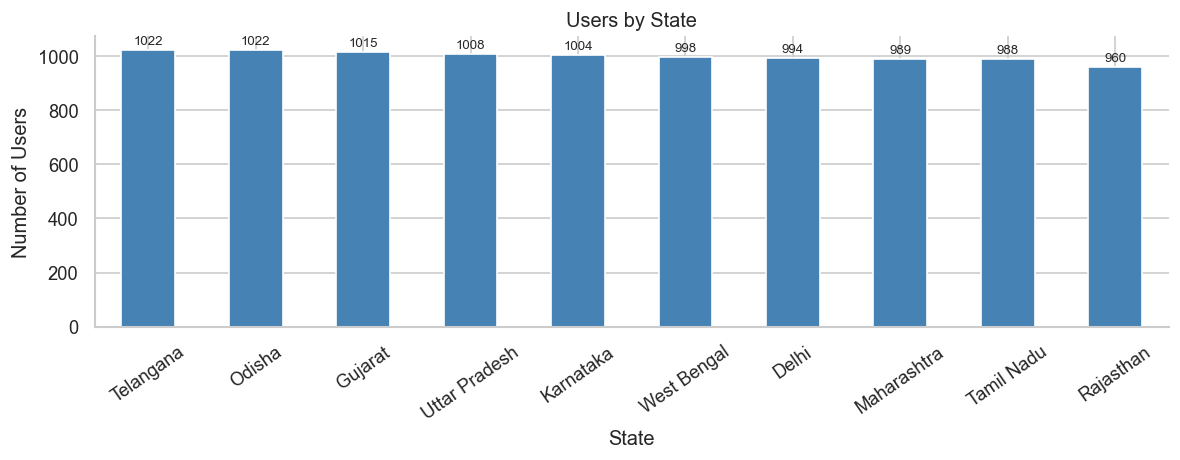

In [2]:
state_counts = user_data['state'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
state_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Users by State')
ax.set_xlabel('State')
ax.set_ylabel('Number of Users')
ax.tick_params(axis='x', rotation=35)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** User distribution across states is relatively uniform since data was synthetically generated with equal probability. In a real dataset, states like Maharashtra and Karnataka typically over-index due to higher urban digital penetration. The key downstream question is not just which state has *more* users, but which state generates *more revenue per user* — that comparison is made in Part 2.

### 1.2 Users by Device

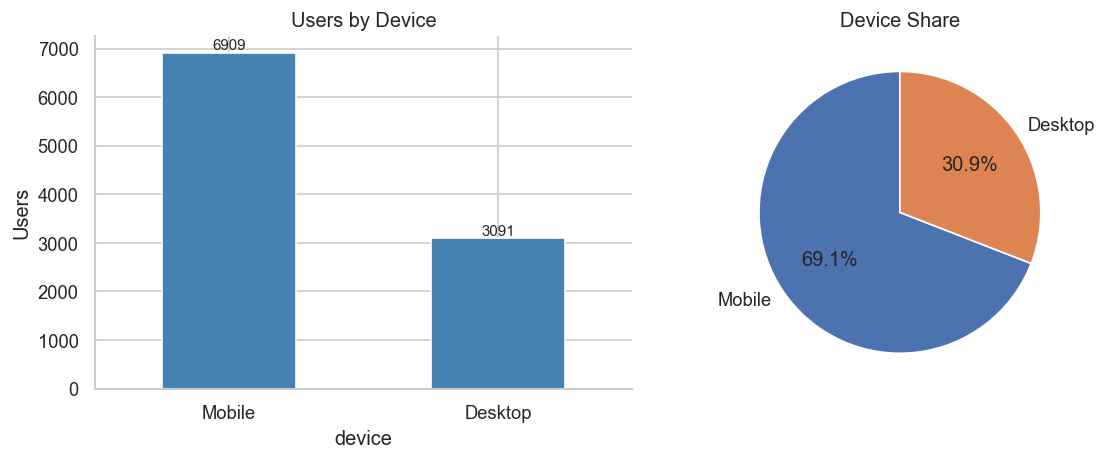

In [3]:
device_counts = user_data['device'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

device_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Users by Device')
axes[0].set_ylabel('Users')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

axes[1].pie(device_counts.values, labels=device_counts.index,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Device Share')

plt.tight_layout()
plt.show()


**Observation:** Mobile accounts for approximately 69% of the user base, which reflects the India market reality where mobile-first access dominates digital financial platforms. This has a direct implication for product design: any friction in the mobile experience (slow load, poor UX flow) will disproportionately affect the majority of users. Later churn analysis compares device-level churn so product decisions are based on behaviour, not just traffic mix.


### 1.3 Users by Acquisition Channel

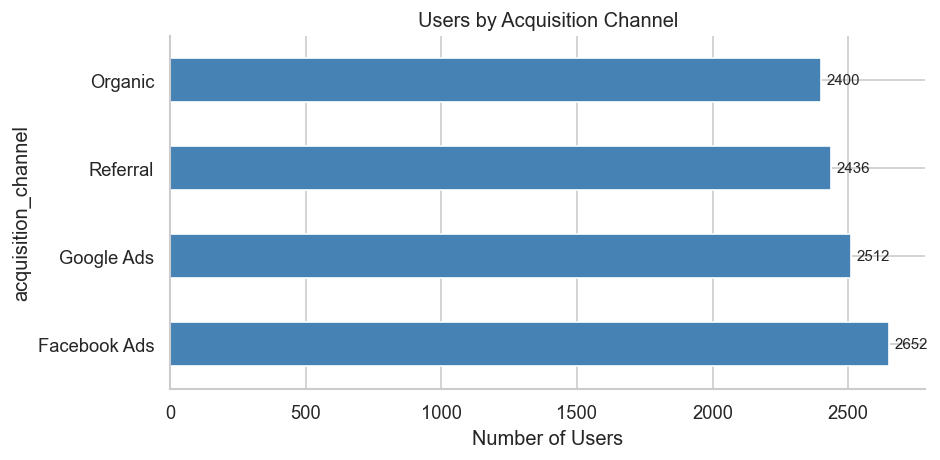

In [4]:
channel_counts = user_data['acquisition_channel'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
channel_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Users by Acquisition Channel')
ax.set_xlabel('Number of Users')
for bar in ax.patches:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** Volume alone across acquisition channels tells an incomplete story. A channel that brings in 3,000 users but churns 60% of them within a month is less valuable than a channel that brings 1,500 users with 80% retention. This plot establishes the volume baseline. The quality comparison — churn rate and revenue per channel — is made in Parts 2 and 4.

### 1.4 Weekly Signup Trend

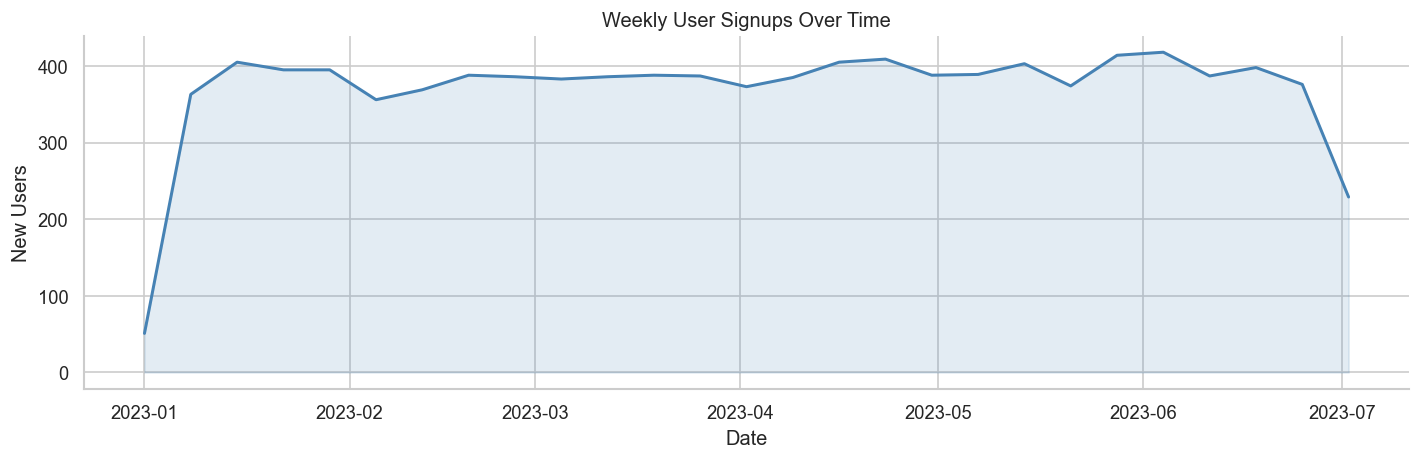

In [5]:
weekly_signups = user_data.set_index('signup_date')['user_id'].resample('W').count()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_signups.index, weekly_signups.values, color='steelblue', linewidth=1.8)
ax.fill_between(weekly_signups.index, weekly_signups.values, alpha=0.15, color='steelblue')
ax.set_title('Weekly User Signups Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('New Users')
plt.tight_layout()
plt.show()

**Observation:** The signup trend over the 6-month window shows whether acquisition is growing, flat, or declining. Any visible spikes should be correlated with campaign start dates from the campaigns table — this linkage is explored in Phase 8 (Marketing Analysis). A flat or declining trend despite ongoing paid campaigns would suggest diminishing returns on ad spend.

---
## Part 2: Revenue Analysis

### 2.1 Revenue Distribution

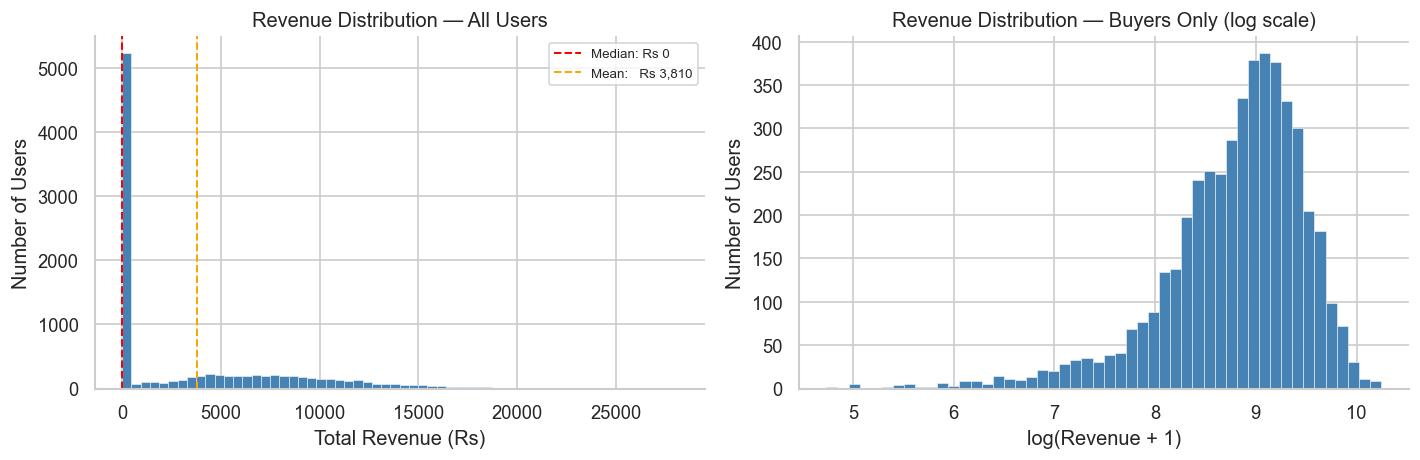

Top 20% of users account for 63.6% of total revenue


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_data['total_revenue'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(user_data['total_revenue'].median(), color='red', linestyle='--', linewidth=1.2,
                label=f'Median: Rs {user_data["total_revenue"].median():,.0f}')
axes[0].axvline(user_data['total_revenue'].mean(), color='orange', linestyle='--', linewidth=1.2,
                label=f'Mean:   Rs {user_data["total_revenue"].mean():,.0f}')
axes[0].set_title('Revenue Distribution — All Users')
axes[0].set_xlabel('Total Revenue (Rs)')
axes[0].set_ylabel('Number of Users')
axes[0].legend(fontsize=8)

buyers = user_data[user_data['total_revenue'] > 0]['total_revenue']
axes[1].hist(np.log1p(buyers), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('Revenue Distribution — Buyers Only (log scale)')
axes[1].set_xlabel('log(Revenue + 1)')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

sorted_rev = user_data['total_revenue'].sort_values(ascending=False)
top20_share = sorted_rev.head(int(len(sorted_rev)*0.2)).sum() / sorted_rev.sum()
print(f'Top 20% of users account for {top20_share:.1%} of total revenue')

**Observation:** Revenue is right-skewed — the mean is significantly higher than the median, indicating that a small proportion of high-spending users inflates the average. The log-scale histogram on active buyers reveals the actual spread of spending behaviour among those who convert. The Pareto ratio printed above confirms whether the classic 80/20 rule holds. This concentration pattern means retention strategy for top spenders is more commercially impactful than broad acquisition campaigns targeting the median user.

### 2.2 Average Revenue per User by State

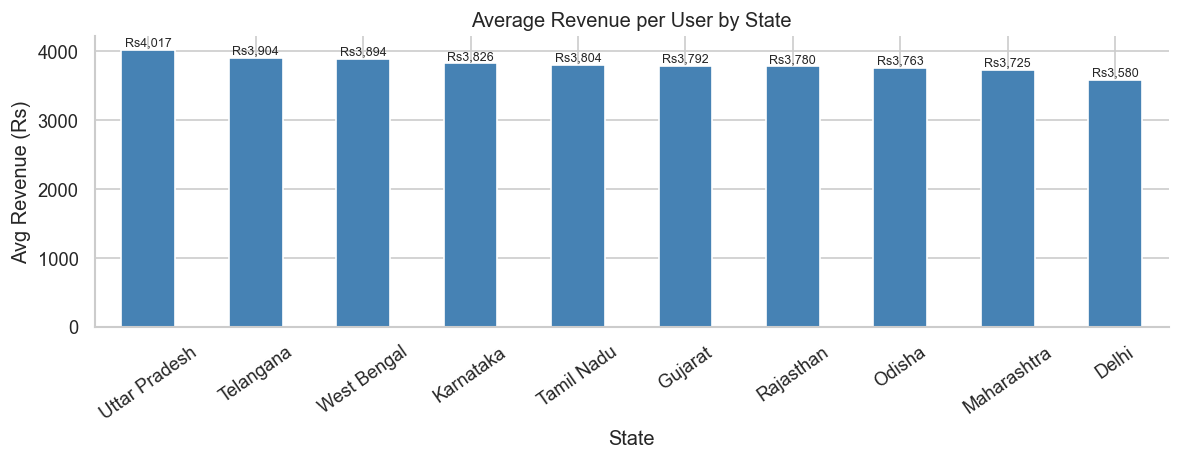

In [7]:
rev_by_state = user_data.groupby('state')['total_revenue'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
rev_by_state.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Revenue per User by State')
ax.set_xlabel('State')
ax.set_ylabel('Avg Revenue (Rs)')
ax.tick_params(axis='x', rotation=35)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'Rs{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.show()

**Observation:** Cross-referencing this with the user count chart from Part 1 reveals which states are high-volume-low-value versus low-volume-high-value. A state in the top 3 for revenue per user but bottom half for user count is a high-priority expansion target — the willingness to spend is already there, only acquisition is lagging.

### 2.3 Average Revenue per User by Acquisition Channel

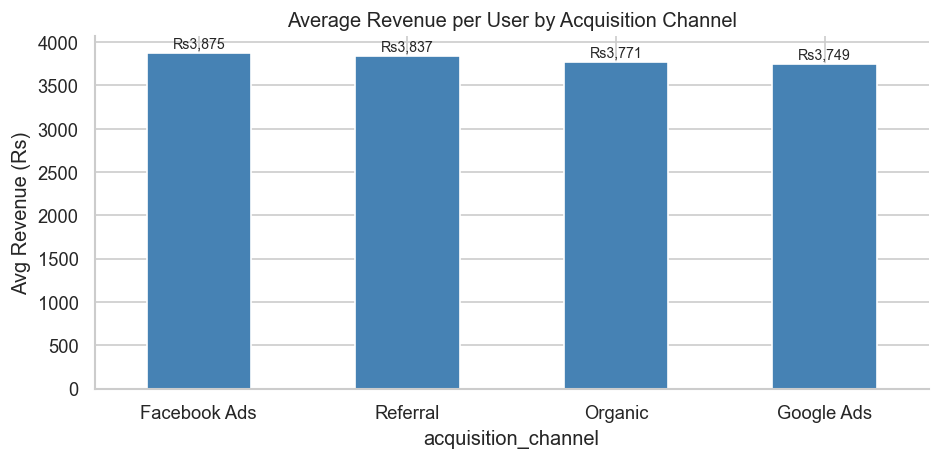

                     user_count  avg_revenue
acquisition_channel                         
Facebook Ads               2652  3875.513198
Referral                   2436  3837.530378
Organic                    2400  3771.147083
Google Ads                 2512  3749.598328


In [8]:
rev_by_channel = user_data.groupby('acquisition_channel').agg(
    user_count  = ('user_id', 'count'),
    avg_revenue = ('total_revenue', 'mean')
).sort_values('avg_revenue', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
rev_by_channel['avg_revenue'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Revenue per User by Acquisition Channel')
ax.set_ylabel('Avg Revenue (Rs)')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'Rs{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.show()

print(rev_by_channel.to_string())

**Observation:** This chart is the first step in CAC vs LTV analysis (Phase 9). If Referral users generate the highest revenue per head but represent a small fraction of total users, the business case for investing in a referral programme becomes clear. If paid channels bring high volume but low revenue per user, that signals a targeting problem — ads are reaching the wrong audience or the landing page is not converting the right intent.

---
## Part 3: Engagement Analysis

### 3.1 Engagement Score Distribution

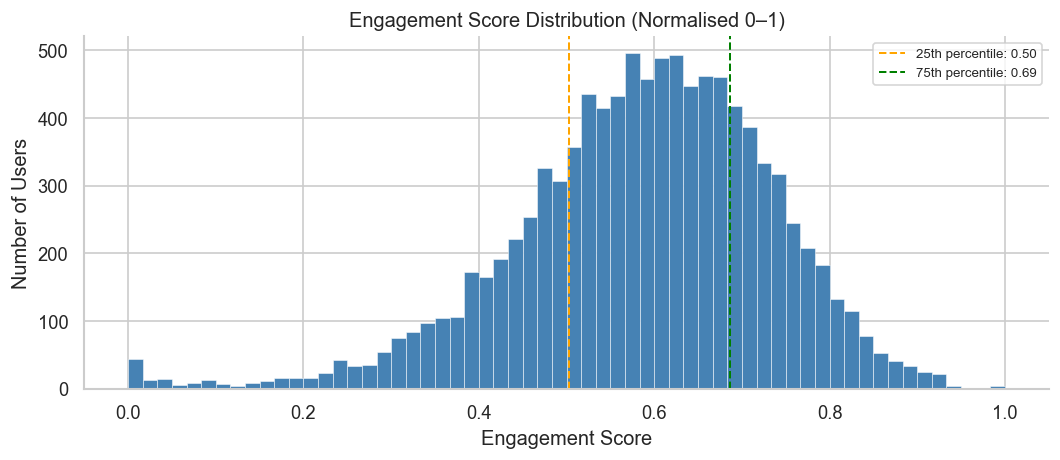

In [9]:
p25 = user_data['engagement_score'].quantile(0.25)
p75 = user_data['engagement_score'].quantile(0.75)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(user_data['engagement_score'], bins=60, color='steelblue',
        edgecolor='white', linewidth=0.3)
ax.axvline(p25, color='orange', linestyle='--', linewidth=1.2,
           label=f'25th percentile: {p25:.2f}')
ax.axvline(p75, color='green',  linestyle='--', linewidth=1.2,
           label=f'75th percentile: {p75:.2f}')
ax.set_title('Engagement Score Distribution (Normalised 0–1)')
ax.set_xlabel('Engagement Score')
ax.set_ylabel('Number of Users')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** Users below the 25th percentile engagement threshold represent the at-risk segment — low session frequency, short durations, and no purchases. These users are approximately 4–6 weeks away from being classified as churned under our 30-day inactivity rule. Identifying them early enables proactive retention interventions such as re-engagement emails or in-app nudges before the churn threshold is crossed.

### 3.2 Sessions vs Revenue — by Churn Status

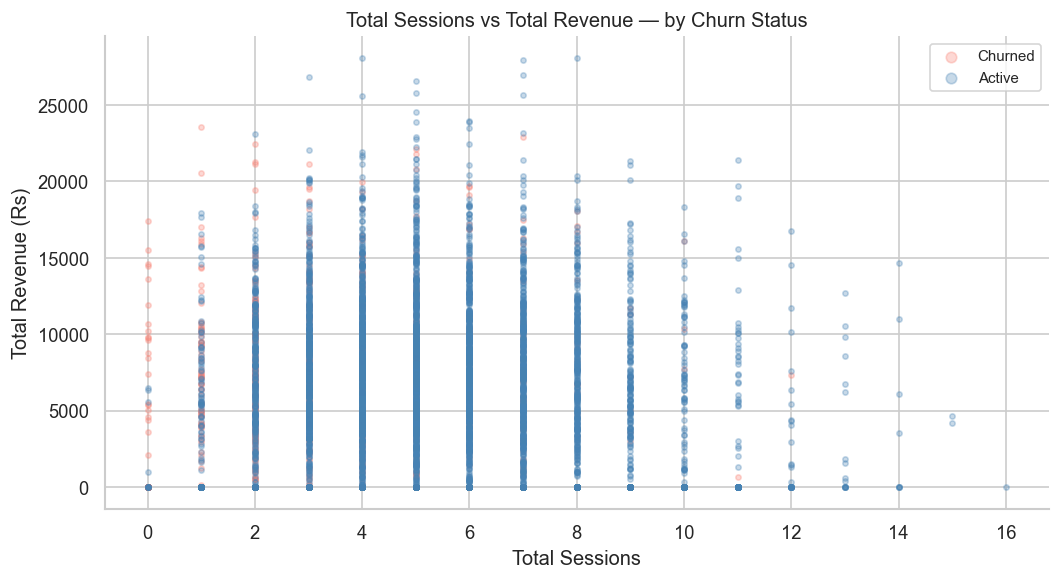

In [10]:
# Split by integer churn value — avoids any string/int palette mismatch
active  = user_data[user_data['churn'] == 0]
churned = user_data[user_data['churn'] == 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(churned['total_sessions'], churned['total_revenue'],
           alpha=0.3, s=10, label='Churned', color='salmon')
ax.scatter(active['total_sessions'],  active['total_revenue'],
           alpha=0.3, s=10, label='Active',  color='steelblue')
ax.set_title('Total Sessions vs Total Revenue — by Churn Status')
ax.set_xlabel('Total Sessions')
ax.set_ylabel('Total Revenue (Rs)')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

**Observation:** Churned users cluster in the bottom-left quadrant — low sessions, low revenue. Active users spread more broadly, with high-session users also generating higher revenue in most cases. This confirms that session count is a leading indicator of both monetisation and retention. The few active users with many sessions but low revenue represent a conversion problem — they are engaged but not purchasing, which may indicate a pricing or product-fit issue.

### 3.3 Engagement Score vs Total Revenue

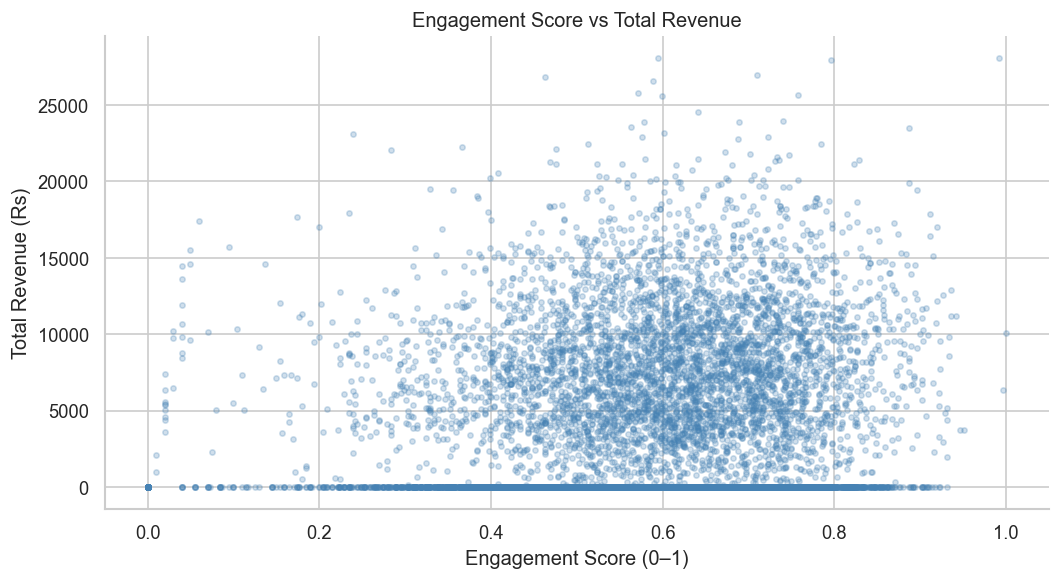

Pearson correlation between engagement score and revenue: 0.118


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(user_data['engagement_score'], user_data['total_revenue'],
           alpha=0.25, s=10, color='steelblue')
ax.set_title('Engagement Score vs Total Revenue')
ax.set_xlabel('Engagement Score (0–1)')
ax.set_ylabel('Total Revenue (Rs)')
plt.tight_layout()
plt.show()

corr = user_data['engagement_score'].corr(user_data['total_revenue'])
print(f'Pearson correlation between engagement score and revenue: {corr:.3f}')

**Observation:** The correlation coefficient quantifies the relationship between engagement and revenue. The relationship is modest and positive, which is expected: engagement captures session behaviour, while revenue is driven by purchase decisions that are not fully explained by session activity alone. Engagement score is useful as an executive diagnostic, but NB07 treats it carefully because its component variables are already available to the model.


---
## Part 4: Churn Analysis

### 4.1 Overall Churn Rate

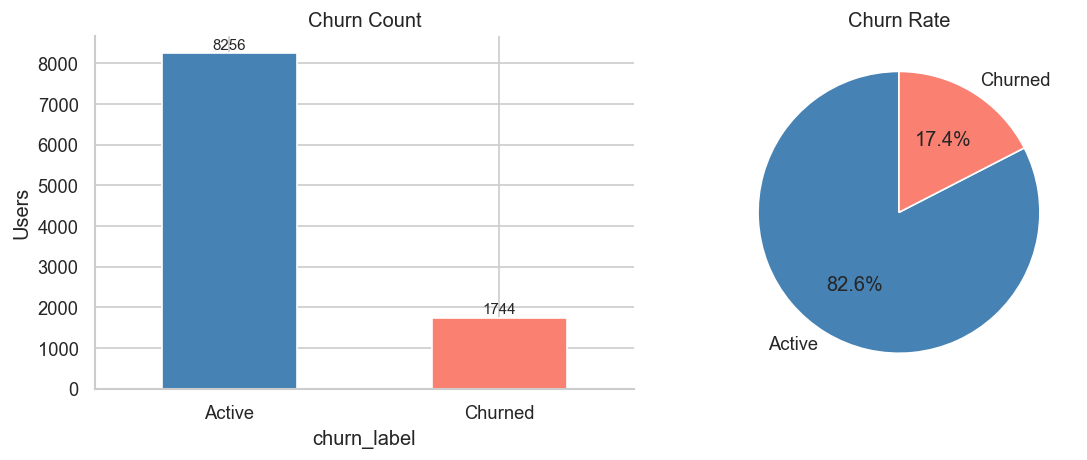

Churn rate: 17.4%


In [12]:
churn_counts = user_data['churn_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Users')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'salmon'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.show()
print(f'Churn rate: {user_data["churn"].mean():.1%}')

**Observation:** This establishes the baseline churn rate for the entire platform. Industry benchmarks for B2C fintech platforms in India typically range between 15–35% on a 30-day inactivity definition. A rate above 40% would indicate a serious product-market fit or onboarding problem. This number will be broken down by acquisition channel, device, and state in the next sections to identify where churn is concentrated.

### 4.2 Churn Rate by Acquisition Channel

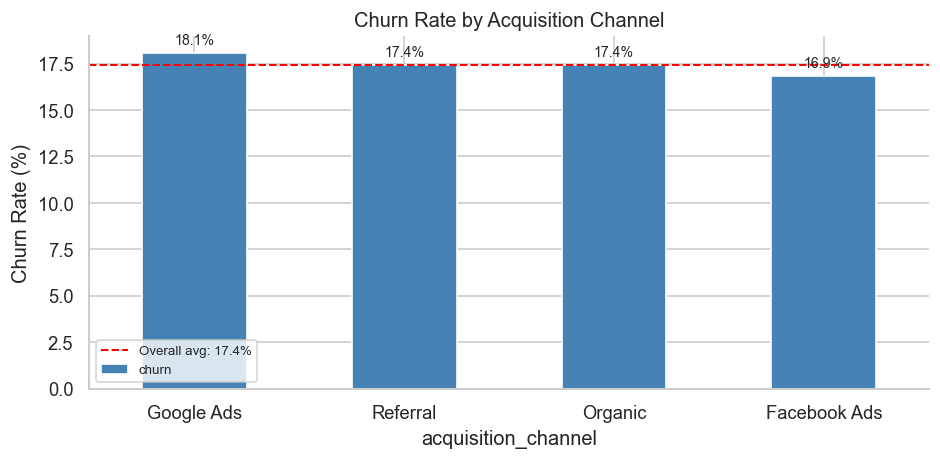

In [13]:
churn_by_channel = (
    user_data.groupby('acquisition_channel')['churn']
    .mean()
    .sort_values(ascending=False) * 100
)
avg_churn = user_data['churn'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
churn_by_channel.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(avg_churn, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_title('Churn Rate by Acquisition Channel')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.show()

**Observation:** Channels above the red average line are underperforming on retention. High churn from a paid channel means marketing spend is acquiring users who do not stick — the CAC is being wasted. The immediate business action is to investigate the post-acquisition journey for high-churn channels: is the landing page misleading user expectations? Is the onboarding flow too complex for that audience segment? This feeds directly into Phase 8 (Marketing Analysis) and Phase 9 (CAC + ROI).

### 4.3 Churn vs Engagement Score & Revenue

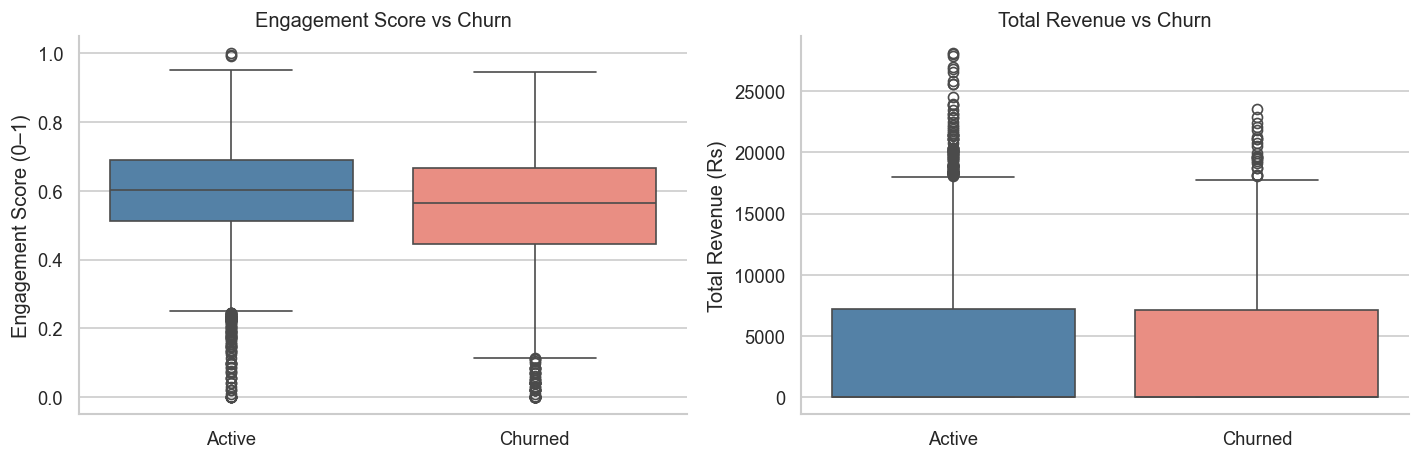

Active   | median engagement: 0.603 | median revenue: Rs 0
Churned  | median engagement: 0.563 | median revenue: Rs 0


In [14]:
# Use churn_label (string) with explicit palette for seaborn — avoids int/str key mismatch
churn_palette = {'Active': 'steelblue', 'Churned': 'salmon'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='churn_label', y='engagement_score', data=user_data,
            palette=churn_palette, order=['Active', 'Churned'], ax=axes[0])
axes[0].set_title('Engagement Score vs Churn')
axes[0].set_xlabel('')
axes[0].set_ylabel('Engagement Score (0–1)')

sns.boxplot(x='churn_label', y='total_revenue', data=user_data,
            palette=churn_palette, order=['Active', 'Churned'], ax=axes[1])
axes[1].set_title('Total Revenue vs Churn')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total Revenue (Rs)')

plt.tight_layout()
plt.show()

for label in ['Active', 'Churned']:
    grp = user_data[user_data['churn_label'] == label]
    print(f'{label:8s} | median engagement: {grp["engagement_score"].median():.3f} '
          f'| median revenue: Rs {grp["total_revenue"].median():,.0f}')

**Observation:** The boxplots confirm two things. First, churned users have a lower median engagement score, so engagement is a meaningful behavioural diagnostic. Second, churned users generate lower revenue, but the overlap in revenue distributions means revenue alone is not a reliable churn predictor. In NB07, engagement score is discussed as a derived composite; the model uses the underlying behavioural components to avoid redundant features.


### 4.4 Churn Rate by Device

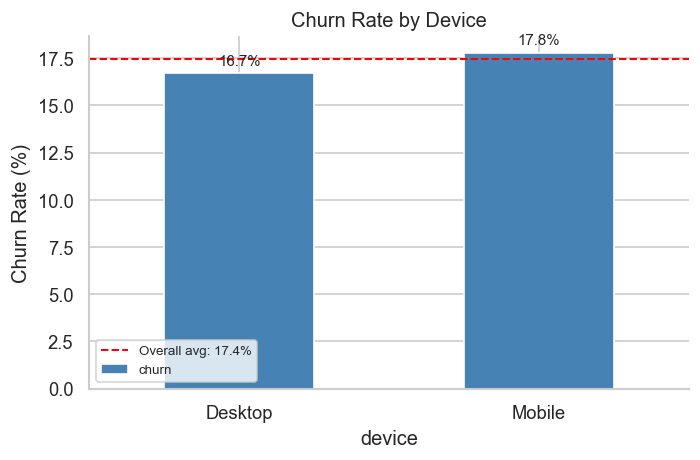

In [15]:
churn_by_device = user_data.groupby('device')['churn'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_device.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(avg_churn, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_title('Churn Rate by Device')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** If mobile churn exceeds desktop churn, this is actionable for the product team — it points to a specific platform experience problem rather than a general product problem. Given that mobile represents 70% of users, even a 5 percentage point difference in churn rate between devices has a large absolute impact on retained user count.

---
## Part 5: Correlation Analysis

### 5.1 Correlation Heatmap — Key Features

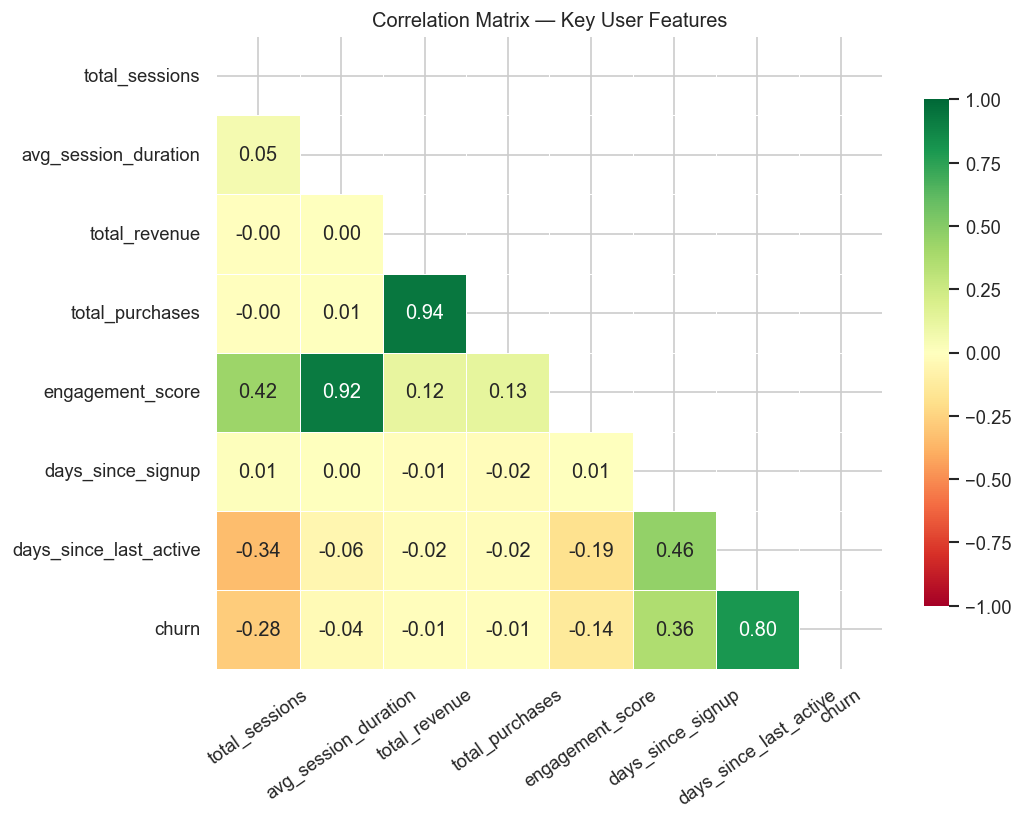

In [16]:
cols = [
    'total_sessions', 'avg_session_duration', 'total_revenue',
    'total_purchases', 'engagement_score', 'days_since_signup',
    'days_since_last_active', 'churn'
]
corr = user_data[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key User Features')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

**Observation:** The correlation matrix gives a full picture of feature relationships before modelling. Key things to look for: (1) strong positive correlation between sessions, purchases, and revenue confirms that activity drives monetisation; (2) negative correlation between engagement score and churn validates engagement as a monitoring signal; (3) high correlation between total_sessions and engagement_score indicates multicollinearity, so NB07 can prefer the underlying components over the composite score.


---
## EDA Summary

In [17]:
print('='*58)
print('  EDA SUMMARY')
print('='*58)
print(f'  Total users              : {len(user_data):,}')
print(f'  Churn rate               : {user_data["churn"].mean():.1%}')
print(f'  Users who purchased      : {user_data["has_purchased"].mean():.1%}')
print(f'  Avg revenue / user       : Rs {user_data["total_revenue"].mean():,.0f}')
print(f'  Median revenue / user    : Rs {user_data["total_revenue"].median():,.0f}')
print(f'  Avg sessions / user      : {user_data["total_sessions"].mean():.1f}')
print(f'  Avg engagement score     : {user_data["engagement_score"].mean():.3f}')
print(f'  Highest churn channel    : {user_data.groupby("acquisition_channel")["churn"].mean().idxmax()}')
print(f'  Highest revenue channel  : {user_data.groupby("acquisition_channel")["total_revenue"].mean().idxmax()}')
print(f'  Top state by user count  : {user_data["state"].value_counts().index[0]}')
print('='*58)
print('\nReady for Phase 5: Funnel Analysis')

  EDA SUMMARY
  Total users              : 10,000
  Churn rate               : 17.4%
  Users who purchased      : 48.0%
  Avg revenue / user       : Rs 3,810
  Median revenue / user    : Rs 0
  Avg sessions / user      : 5.0
  Avg engagement score     : 0.586
  Highest churn channel    : Google Ads
  Highest revenue channel  : Facebook Ads
  Top state by user count  : Telangana

Ready for Phase 5: Funnel Analysis


---
## Key Findings

**1. Revenue is concentrated, not distributed.**  
The right-skewed distribution and Pareto check show that a minority of users drive the majority of revenue. Retention and upsell strategy for this group is more commercially impactful than broad acquisition.

**2. Engagement score is a useful monitoring signal, not a standalone answer.**  
The boxplot and correlation show churned users have lower engagement scores on average, but the relationship is modest. For modelling, NB07 uses the underlying behavioural components instead of relying on the composite score directly.

**3. Acquisition channel affects not just volume but quality.**  
Different channels produce users with different churn rates and revenue levels. High-volume channels that also produce high churn are net negative on CAC efficiency; this is quantified in Phase 9.

**4. Mobile dominance has retention implications.**  
With 70% of users on mobile, device-specific churn differences are amplified at scale. Product improvements on mobile have disproportionate platform-wide impact.

**5. Session count is both a revenue and retention predictor.**  
The scatter plot shows that high-session users generate more revenue and are less likely to churn. Increasing session frequency through notifications, recommendations, or feature releases is a dual-benefit lever.
